<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# **Procesamiento de Lenguaje Natural**
## Cristian Aballay A2301
## **Desafio, Traductor**

### **Consigna**

#### Replicar el modelo traductor desarrollado en clase (https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/blob/may_2026/Clase%206/C%C3%B3digo/Traductor.ipynb) y extender su entrenamiento utilizando un conjunto de datos mÃ¡s amplio y secuencias de mayor longitud.

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model
import pickle
import os
import zipfile
from keras.utils import to_categorical
from tensorflow import keras

In [4]:
if not os.path.exists('spa-eng'):
    os.system("curl -L -o spa-eng.zip http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip")
    
with zipfile.ZipFile('spa-eng.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

with open("./spa-eng/spa.txt") as f:
    lines = f.read().split("\n")[:-1]

In [5]:
MAX_NUM_SENTENCES = 10000

np.random.seed(79)
np.random.shuffle(lines)
input_sentences, output_sentences, output_sentences_inputs = [], [], []

for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break
    if '\t' not in line:
        continue
    input_sentence, output = line.rstrip().split('\t')[:2]
    output_sentences.append(output + ' <eos>')
    output_sentences_inputs.append('<sos> ' + output)
    input_sentences.append(input_sentence)

print(f"Oraciones cargadas: {len(input_sentences)}")
print(input_sentences[0])
print(output_sentences[0])
print(output_sentences_inputs[0])

Oraciones cargadas: 10000
Please knock on the door before you enter.
Por favor, llama antes de entrar. <eos>
<sos> Por favor, llama antes de entrar.


In [6]:
MAX_VOCAB_SIZE = 8000

input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index

output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;=Â¿?@[\\]^_`{|}~\t\n'
)

output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs = output_tokenizer.word_index

# Se suma 1 para incluir el token de palabra desconocida
num_words_output = min(len(word2idx_outputs)+1, MAX_VOCAB_SIZE)

max_input_len = 20
max_out_len   = 22

print(f"Vocabulario EN: {len(word2idx_inputs)} | ES: {len(word2idx_outputs)}")
print(f"max_input_len={max_input_len}  max_out_len={max_out_len}")

Vocabulario EN: 5030 | ES: 7781
max_input_len=20  max_out_len=22


In [7]:
encoder_input_sequences  = pad_sequences(input_integer_seq,        maxlen=max_input_len)
decoder_input_sequences  = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
decoder_output_sequences = pad_sequences(output_integer_seq,       maxlen=max_out_len, padding='post')

print(encoder_input_sequences[0])
print(decoder_input_sequences[0])
print(decoder_output_sequences[0])

[   0    0    0    0    0    0    0    0    0    0    0    0   79 2672
   30    1  244  138    4 1279]
[3422   15   69  628  109    2  533    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]
[ 15  69 628 109   2 533   1   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0]


In [8]:
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, num_classes):

    n = len(enc_seqs)

    def generator():
        for i in range(n):
            yield (
                enc_seqs[i].astype(np.int32),
                dec_in_seqs[i].astype(np.int32),
                dec_out_seqs[i].astype(np.int32),
            )

    def encode_one_hot(enc, dec_in, dec_out):
        y = tf.one_hot(dec_out, depth=num_classes)          # shape (max_out_len, num_classes)
        return (enc, dec_in), y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(max_input_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
        )
    )
    ds = ds.map(encode_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [9]:
def _is_valid_pickle(path):
    try:
        with open(path, 'rb') as f:
            head = f.read(20)
        return b'<html' not in head.lower() and b'<!doctype' not in head.lower()
    except Exception:
        return False

_PKL_PATH = 'gloveembedding.pkl'
_FILE_ID  = '1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94'

if not os.path.exists(_PKL_PATH) or not _is_valid_pickle(_PKL_PATH):
    print("Descargando gloveembedding.pkl desde Google Drive...")
    if os.path.exists(_PKL_PATH):
        os.remove(_PKL_PATH)
    try:
        import gdown
        gdown.download(id=_FILE_ID, output=_PKL_PATH, quiet=False)
    except Exception:
        os.system(f"curl -L -o {_PKL_PATH} "
                  f"'https://drive.google.com/u/0/uc?id={_FILE_ID}&export=download&confirm=t'")
    if not _is_valid_pickle(_PKL_PATH):
        raise ValueError("El archivo descargado no es un pickle vÃ¡lido.")
    print("Descarga completada.")
else:
    print("gloveembedding.pkl ya disponible.")

gloveembedding.pkl ya disponible.


In [10]:
def load_glove_embeddings(pkl_path):
    """Carga el pickle de GloVe y devuelve (word2idx, matrix_fn)."""
    max_bytes = 2**28 - 1
    raw = bytearray()
    sz  = os.path.getsize(pkl_path)
    with open(pkl_path, 'rb') as f:
        for _ in range(0, sz, max_bytes):
            raw += f.read(max_bytes)
    embeddings = pickle.loads(raw)
    idx_array  = np.arange(embeddings.shape[0])
    word2idx   = dict(zip(embeddings['word'], idx_array))
    return embeddings, word2idx

def get_word_embedding(word, embeddings, word2idx, n_features=50):
    i = word2idx.get(word, -1)
    return embeddings[i]['embedding'] if i != -1 else np.zeros(n_features)

def build_embedding_matrix(word2idx_inputs, embeddings, word2idx_glove,
                            nb_words, embed_dim=50):
    matrix = np.zeros((nb_words, embed_dim))
    for word, i in word2idx_inputs.items():
        if i < nb_words:
            vec = get_word_embedding(word, embeddings, word2idx_glove, embed_dim)
            if vec is not None and len(vec) > 0:
                matrix[i] = vec
    return matrix

In [11]:
EMBED_DIM = 50
nb_words  = min(MAX_VOCAB_SIZE, len(word2idx_inputs) + 1)

glove_embeddings, glove_word2idx = load_glove_embeddings(_PKL_PATH)
embedding_matrix = build_embedding_matrix(
    word2idx_inputs, glove_embeddings, glove_word2idx, nb_words, EMBED_DIM
)
print(f"Embeddings nulos: {np.sum(np.sum(embedding_matrix**2, axis=1) == 0)}")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Embeddings nulos: 217
Embedding matrix shape: (5031, 50)


In [12]:
BATCH_SIZE = 64
val_split  = 0.20
split_idx  = int(len(encoder_input_sequences) * (1 - val_split))

train_ds = make_dataset(
    encoder_input_sequences[:split_idx],
    decoder_input_sequences[:split_idx],
    decoder_output_sequences[:split_idx],
    BATCH_SIZE, num_words_output
)
val_ds = make_dataset(
    encoder_input_sequences[split_idx:],
    decoder_input_sequences[split_idx:],
    decoder_output_sequences[split_idx:],
    BATCH_SIZE, num_words_output
)

#### Modificar valores de hiperparÃ¡metros (por ejemplo, el nÃºmero de unidades en las capas LSTM) y analizar su impacto en el desempeÃ±o del traductor.

Se considerara para analizar 
* el numero de unidades de las capas LTSM: [64, 128, 256, 512]
    - Se reduce para ver el comportamiento del modelo con menos capacidad de parametros de entrada y se entrene mas rapido. Por otro lado se aumenta para que tenga mas capacidad, pero se reducira el entrenamiento
* el rate de la capa de dropout: [0.1, 0.15, 0.2, 0.3]
    - Se testean distintas configuraciones de regularizacion modificando el rate del dropout para reducir o aumentar, para que el modelo no dependa de ninguna dimension con mayor peso
* el learning rate del optimizador: [0.01, 0.001, 1e-4]
    - Para que el modelo pueda converger en mayor o menor medida
* Nro de epocas: 20
    - Se reduce para reducir el tiempo de entrenamiento en los modelos

In [14]:
def build_encoder(nb_words, embed_dim, embedding_matrix, max_input_len, n_units, rate=0.3):

    enc_inputs   = Input(shape=(max_input_len,), name='encoder_inputs')

    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        input_length=max_input_len,
        weights=[embedding_matrix],
        trainable=False,
        name='encoder_embedding'
    )
    enc_emb = Dropout(rate, name='encoder_dropout')(enc_emb_layer(enc_inputs))

    enc_lstm_layer = LSTM(n_units, return_state=True, name='encoder_lstm')
    _, state_h, state_c = enc_lstm_layer(enc_emb)

    return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer

def build_decoder(num_words_output, max_out_len, n_units, encoder_states, rate=0.3):

    dec_inputs = Input(shape=(max_out_len,), name='decoder_inputs')

    dec_emb_layer = Embedding(
        input_dim=num_words_output,
        output_dim=n_units,
        input_length=max_out_len,
        name='decoder_embedding'
    )
    dec_emb = Dropout(rate, name='decoder_dropout')(dec_emb_layer(dec_inputs))

    dec_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True,
                          name='decoder_lstm')
    dec_out, _, _  = dec_lstm_layer(dec_emb, initial_state=encoder_states)

    dec_dense_layer = Dense(num_words_output, activation='softmax', name='decoder_dense')
    dec_out         = dec_dense_layer(dec_out)

    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer

In [ ]:
# Configuramos que hiperparÃ¡metros vamos a probar para cada modelo
n_units = [64, 128, 256, 512]
rates = [0.1, 0.15, 0.2, 0.3]
lrs = [0.1, 0.01, 0.001, 0.0001]

In [ ]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True, verbose=1
)
histories = []
for n_units, rate, lr in zip(n_units, rates, lrs):
    if (os.path.exists(f"seq2seq_n{n_units}_r{rate}_lr{lr}.keras")):
        print(f"Modelo con n_units={n_units}, rate={rate}, lr={lr} ya existe. Saltando entrenamiento.")
        continue 
    print(f"Entrenando modelo con n_units={n_units}, rate={rate}, lr={lr}")
    break
    

    enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
        nb_words, EMBED_DIM, embedding_matrix, max_input_len, n_units, rate
    )
    dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
        num_words_output, max_out_len, n_units, enc_states, rate
    )
    model = Model([enc_inputs, dec_inputs], dec_outputs)
    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        metrics=['accuracy']
    )
    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        callbacks=[lr_scheduler, early_stop]
    )
    # Guardar el modelo entrenado para no volverlo a generar, y reutilizarlo en caso de que se quiera testear
    model.save(f"seq2seq_n{n_units}_r{rate}_lr{lr}.keras")
    histories.append((n_units, rate, lr, hist.history))

Modelo con n_units=64, rate=0.1, lr=0.1 ya existe. Saltando entrenamiento.
Modelo con n_units=128, rate=0.15, lr=0.01 ya existe. Saltando entrenamiento.
Modelo con n_units=256, rate=0.2, lr=0.001 ya existe. Saltando entrenamiento.
Modelo con n_units=512, rate=0.3, lr=0.0001 ya existe. Saltando entrenamiento.


In [ ]:
# Guardar los historiales de entrenamiento en un archivo .npy para su posterior anÃ¡lisis
if not os.path.exists("histories.npy"):
    np.save("histories.npy", histories)

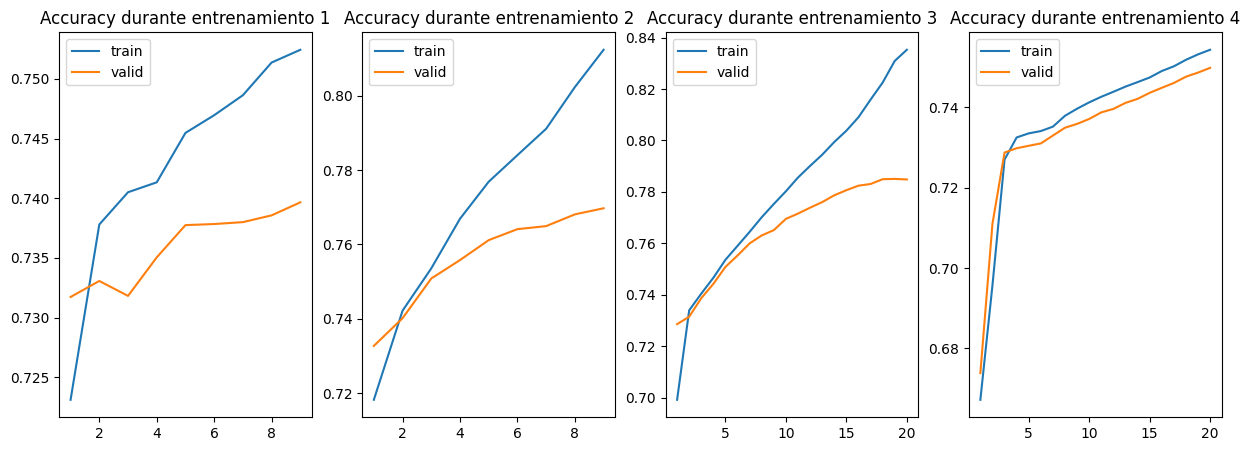

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

if (histories is None or len(histories) == 0):
    histories = np.load("histories.npy", allow_pickle=True)

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(15, 5))

epoch_count = range(1, len(histories[0][3]['accuracy']) + 1)
sns.lineplot(x=epoch_count, y=histories[0][3]['accuracy'],     label='train', ax=axs[0])
sns.lineplot(x=epoch_count, y=histories[0][3]['val_accuracy'], label='valid', ax=axs[0])
axs[0].set_title("Accuracy durante entrenamiento 1")

epoch_count = range(1, len(histories[1][3]['accuracy']) + 1)
sns.lineplot(x=epoch_count, y=histories[1][3]['accuracy'],     label='train', ax=axs[1])
sns.lineplot(x=epoch_count, y=histories[1][3]['val_accuracy'], label='valid', ax=axs[1])
axs[1].set_title("Accuracy durante entrenamiento 2")

epoch_count = range(1, len(histories[2][3]['accuracy']) + 1)
sns.lineplot(x=epoch_count, y=histories[2][3]['accuracy'],     label='train', ax=axs[2])
sns.lineplot(x=epoch_count, y=histories[2][3]['val_accuracy'], label='valid', ax=axs[2])
axs[2].set_title("Accuracy durante entrenamiento 3")

epoch_count = range(1, len(histories[3][3]['accuracy']) + 1)
sns.lineplot(x=epoch_count, y=histories[3][3]['accuracy'],     label='train', ax=axs[3])
sns.lineplot(x=epoch_count, y=histories[3][3]['val_accuracy'], label='valid', ax=axs[3])
axs[3].set_title("Accuracy durante entrenamiento 4")
plt.show()

Vemos que todos tienen aproximacamente el mismo acurrancy de entrenamiento, entre los 4 el mejor es con la configuracion de hiperparametros n_units=256, rate=0.2, lr=0.001 

In [21]:
print("Mejores resultados:")
for n_units, rate, lr, hist in histories:
    best_epoch = np.argmin(hist['val_loss'])
    print(f"n_units={n_units}, rate={rate}, lr={lr} | "
          f"Best Epoch: {best_epoch+1}, "
          f"Val Loss: {hist['val_loss'][best_epoch]:.4f}, "
          f"Val Accuracy: {hist['val_accuracy'][best_epoch]:.4f}")

Mejores resultados:
n_units=64, rate=0.1, lr=0.1 | Best Epoch: 5, Val Loss: 1.9075, Val Accuracy: 0.7377
n_units=128, rate=0.15, lr=0.01 | Best Epoch: 5, Val Loss: 1.6634, Val Accuracy: 0.7612
n_units=256, rate=0.2, lr=0.001 | Best Epoch: 20, Val Loss: 1.4747, Val Accuracy: 0.7848
n_units=512, rate=0.3, lr=0.0001 | Best Epoch: 20, Val Loss: 1.7722, Val Accuracy: 0.7499


#### Analizar el impacto del nÃºmero de neuronas en las capas recurrentes, comparando el desempeÃ±o de distintas configuraciones del modelo.

Se modificara el modelo agregando capas adicionales de LSMT, como el conjunto de entrenamiento es pequeÃ±o, se agragara solo una capa adicional de LSTM tanto en el encoder como en el decoder.

Se toman los hiperparametros del mejor modelo para comparar el desempeÃ±o de ambos

Para eso redefinimos las funciones de encoder y decoder agregando la capa adicional

In [ ]:
def build_encoder_2(nb_words, embed_dim, embedding_matrix, max_input_len, n_units, rate=0.3):

    enc_inputs   = Input(shape=(max_input_len,), name='encoder_inputs')

    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        input_length=max_input_len,
        weights=[embedding_matrix],
        trainable=False,
        name='encoder_embedding'
    )
    enc_emb = Dropout(rate, name='encoder_dropout')(enc_emb_layer(enc_inputs))
    # en la primer capa LSTM, se devuelve la secuencia completa de estados ocultos, para que la segunda capa LSTM pueda procesarla
    enc_lstm_layer_1 = LSTM(n_units, return_sequences=True, return_state=True, name='encoder_lstm_1')
    secuences , _, _ = enc_lstm_layer_1(enc_emb)
    # en la segunda capa LSTM, se devuelve solo el Ãºltimo estado oculto y el estado de celda, que se usarÃ¡n como estados iniciales para el decodificador
    enc_lstm_layer_2 = LSTM(n_units, return_state=True, name='encoder_lstm_2')
    _, state_h, state_c = enc_lstm_layer_2(secuences)

    return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer_2

def build_decoder_2(num_words_output, max_out_len, n_units, encoder_states, rate=0.3):

    dec_inputs = Input(shape=(max_out_len,), name='decoder_inputs')

    dec_emb_layer = Embedding(
        input_dim=num_words_output,
        output_dim=n_units,
        input_length=max_out_len,
        name='decoder_embedding'
    )
    dec_emb = Dropout(rate, name='decoder_dropout')(dec_emb_layer(dec_inputs))
    # en la primer capa LSTM, se devuelve la secuencia completa de estados ocultos, para que la segunda capa LSTM pueda procesarla
    dec_lstm_layer_1 = LSTM(n_units, return_sequences=True, return_state=True,
                          name='decoder_lstm_1')
    dec_out, _, _  = dec_lstm_layer_1(dec_emb, initial_state=encoder_states)
    # en la segunda capa LSTM, se devuelve la secuencia completa de estados ocultos, para que la capa densa pueda procesarla
    dec_lstm_layer_2 = LSTM(n_units, return_sequences=True, return_state=True,
                          name='decoder_lstm_2')
    dec_out, _, _  = dec_lstm_layer_2(dec_out)

    dec_dense_layer = Dense(num_words_output, activation='softmax', name='decoder_dense')
    dec_out         = dec_dense_layer(dec_out)

    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer_2, dec_dense_layer

In [23]:
n_units = histories[2][0]  # Mejor n_units segÃºn los resultados
rate = histories[2][1]     # Mejor rate segÃºn los resultados
lr = histories[2][2]      # Mejor lr segÃºn los resultados

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True, verbose=1
)
if (not os.path.exists(f"seq2seq_2_n{n_units}_r{rate}_lr{lr}.keras")):
    print(f"Entrenando modelo de 2 capas LSTM con n_units={n_units}, rate={rate}, lr={lr}")
    enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder_2(
        nb_words, EMBED_DIM, embedding_matrix, max_input_len, n_units, rate
    )
    dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder_2(
        num_words_output, max_out_len, n_units, enc_states, rate
    )
    model = Model([enc_inputs, dec_inputs], dec_outputs)
    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        metrics=['accuracy']
    )
    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        callbacks=[lr_scheduler, early_stop]
    )
    model.save(f"seq2seq_2_n{n_units}_r{rate}_lr{lr}.keras")
    np.save("history_2.npy", hist)
else:
    print(f"Modelo de 2 capas LSTM con n_units={n_units}, rate={rate}, lr={lr} ya existe. Cargando modelo.")
    model = keras.models.load_model(f"seq2seq_2_n{n_units}_r{rate}_lr{lr}.keras")
    hist = np.load("history_2.npy", allow_pickle=True).item()

Modelo de 2 capas LSTM con n_units=256, rate=0.2, lr=0.001 ya existe. Cargando modelo.


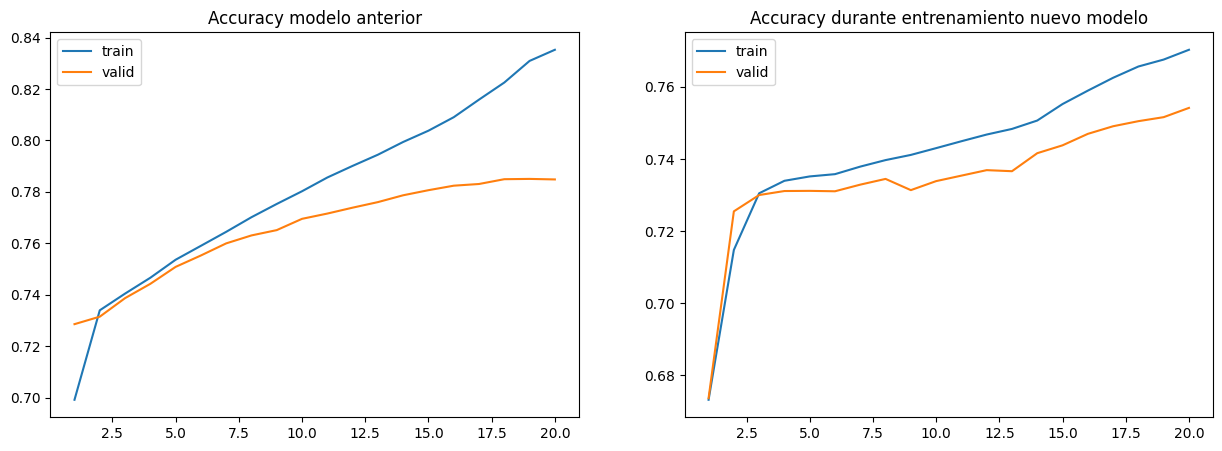

In [24]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

epoch_count = range(1, len(histories[2][3]['accuracy']) + 1)
sns.lineplot(x=epoch_count, y=histories[2][3]['accuracy'],     label='train', ax=axs[0])
sns.lineplot(x=epoch_count, y=histories[2][3]['val_accuracy'], label='valid', ax=axs[0])
axs[0].set_title("Accuracy modelo anterior")

epoch_count = range(1, len(hist.history['accuracy']) + 1)
sns.lineplot(x=epoch_count, y=hist.history['accuracy'],     label='train', ax=axs[1])
sns.lineplot(x=epoch_count, y=hist.history['val_accuracy'], label='valid', ax=axs[1])
axs[1].set_title("Accuracy durante entrenamiento nuevo modelo")
plt.show()

La primera conclusion que se puede sacar es que el modelo demora mas tiempo en entrenar.
En cuanto al rendimiento, tal como se puede ver en el grafico, el desempeÃ±o es mejor con el modelo anterior, pero pareciera tender a tener menor overfiting. Aun asi no hay mucha diferencia. En teoria el modelo funcionaria mejor con mayor numero de parametros de entrada y un mayor numero de palablabras de muestreo

#### Generar y presentar al menos cinco ejemplos de traducciones producidas por el modelo entrenado.

In [25]:
model = keras.models.load_model("seq2seq_2_n256_r0.2_lr0.001.keras")

In [29]:
enc_inputs   = Input(shape=(max_input_len,), name='encoder_inputs')

In [30]:
enc_emb_layer = model.get_layer('encoder_embedding')
enc_lstm_layers = [model.get_layer('encoder_lstm_1'), model.get_layer('encoder_lstm_2')]
dec_emb_layer = model.get_layer('decoder_embedding')
dec_lstm_layers = [model.get_layer('decoder_lstm_1'), model.get_layer('decoder_lstm_2')]
dec_dense_layer = model.get_layer('decoder_dense')

In [31]:
def build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layers, n_units):
    """Modelo de encoder que solo devuelve los estados."""
    enc_emb = enc_emb_layer(enc_inputs)                    # reutiliza pesos entrenados
    if len(enc_lstm_layers) > 1:
        for lstm in enc_lstm_layers[:-1]:
             enc_emb, _, _ = lstm(enc_emb)
    _, state_h, state_c = enc_lstm_layers[-1](enc_emb)

    return Model(enc_inputs, [state_h, state_c])


def build_decoder_inference(dec_emb_layer, dec_lstm_layers, dec_dense_layer, n_units):
    """
    Modelo de decoder paso a paso (un token por vez).
    Maneja estados de TODAS las capas LSTM para coherencia con el entrenamiento.
    En entrenamiento: encoder_states -> LSTM_1; LSTM_2 sin estado inicial.
    En inferencia: pasamos h1,c1 a LSTM_1 y h2,c2 a LSTM_2 para propagar
    correctamente los estados entre pasos de decodificacion.
    """
    dec_input_single = Input(shape=(1,), name='dec_input_single')

    # Un par de estados (h, c) por cada capa LSTM
    state_inputs = []
    for i in range(len(dec_lstm_layers)):
        state_inputs.append(Input(shape=(n_units,), name=f'dec_state_h_{i}'))
        state_inputs.append(Input(shape=(n_units,), name=f'dec_state_c_{i}'))

    dec_emb_single = dec_emb_layer(dec_input_single)      # reutiliza pesos entrenados

    x = dec_emb_single
    state_outputs = []
    for i, lstm in enumerate(dec_lstm_layers):
        h_in = state_inputs[i * 2]
        c_in = state_inputs[i * 2 + 1]
        x, h_out, c_out = lstm(x, initial_state=[h_in, c_in])
        state_outputs.append(h_out)
        state_outputs.append(c_out)

    dec_out = dec_dense_layer(x)

    return Model(
        [dec_input_single] + state_inputs,
        [dec_out] + state_outputs
    )

encoder_model = build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layers, n_units)
decoder_model = build_decoder_inference(dec_emb_layer, dec_lstm_layers, dec_dense_layer, n_units)

idx2word_input  = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

def translate_sentence(input_seq):
    # El encoder devuelve los estados de su ultima LSTM (h, c)
    h1, c1 = encoder_model.predict(input_seq, verbose=0)
    # LSTM_2 del decoder arranca con estados en cero
    h2 = np.zeros((1, n_units))
    c2 = np.zeros((1, n_units))

    target_seq      = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(max_out_len):
        # decoder_model retorna: [token_probs, h1_new, c1_new, h2_new, c2_new]
        results = decoder_model.predict(
            [target_seq, h1, c1, h2, c2], verbose=0
        )
        output_tokens = results[0]
        h1, c1 = results[1], results[2]
        h2, c2 = results[3], results[4]

        idx = np.argmax(output_tokens[0, 0, :])
        if idx == eos:
            break
        if idx > 0:
            output_sentence.append(idx2word_target[idx])
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)


def translate(text):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_sentence(seq)

In [32]:
print("\n--- Ejemplos ---")
for s in ["What is my name?", "My favorite color is green.", "I love coding.", "Where are you from?", "My dog is cute."]:
    print(f"EN: {s}")
    print(f"ES: {translate(s)}\n")


--- Ejemplos ---
EN: What is my name?
ES: quÃ© es un

EN: My favorite color is green.
ES: el libro se dio un

EN: I love coding.
ES: no te gustan

EN: Where are you from?
ES: por quÃ© es

EN: My dog is cute.
ES: el libro es muy



#### Interpretar a detalle los resultados obtenidos, considerando mÃ©tricas de evaluaciÃ³n, calidad de las traducciones y posibles limitaciones del enfoque utilizado.

En principio parece que el modelo tendrÃ­a que funcionar muy bien por el accuracy alcanzado. Pero la calidad de las traducciones no reflejan el objetivo que se desea. La realidad es que las respuestas no tienen que ver demasiado con la traducciÃ³n pero tradaccion no esta muy alejado.

Quizas lo mejor es poder consumir todo el dataset y todo el vocabulario, pero la cantidad de RAM no es suficiente y el entrenamiento excede a la evalucacion en general. Por eso se guardaban los modelos, para no reentrenar y volver a evaluar.



### **Actividades opcionales**

### Incorporar embeddings preentrenados para ambos idiomas y evaluar su efecto sobre el rendimiento del modelo.

### Experimentar con diferentes estrategias de generaciÃ³n de secuencias, como muestreo aleatorio (sampling) o bÃºsqueda por haz (beam search).


#### mplementar y entrenar una versiÃ³n equivalente del modelo utilizando PyTorch, comparando los resultados con la implementaciÃ³n original.